In [3]:
import pandas as pd
import numpy as np
from scipy.stats import norm

GEOMETRIC BROWNIAN MOTION

In [4]:
def simulate_gbm_vectorized(S0, mu, sigma, T, n_steps):
    dt = T / n_steps
    Z = np.random.normal(0, 1, n_steps)

    increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_path = np.cumsum(increments)

    S = S0 * np.exp(np.insert(log_path, 0, 0))
    return S

<Axes: title={'center': 'Simulated Geometric Brownian Motion'}>

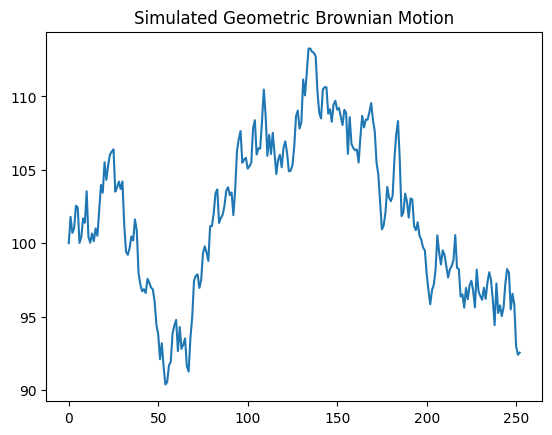

In [5]:
x = simulate_gbm_vectorized(S0=100, mu=0.05, sigma=0.2, T=1, n_steps=252)
x = pd.Series(x)
x.plot(title="Simulated Geometric Brownian Motion")

GBM - multiple path

In [6]:
def simulate_gbm_mc(S0, mu, sigma, T, n_steps, n_paths):
    dt = T / n_steps
    Z = np.random.normal(0, 1, (n_paths, n_steps))

    increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(increments, axis=1)

    S = S0 * np.exp(np.hstack([np.zeros((n_paths, 1)), log_paths]))
    return S

<Axes: title={'center': 'Simulated Geometric Brownian Motion (1000 paths)'}>

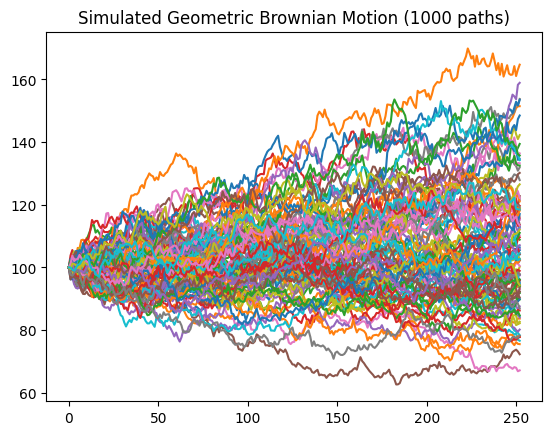

In [10]:
x = simulate_gbm_mc(S0=100, mu=0.05, sigma=0.2, T=1, n_steps=252, n_paths=100)
x = pd.DataFrame(x)
x.T.plot(legend=False, title="Simulated Geometric Brownian Motion (1000 paths)")

ARITHMETIC BROWNIAN MOTION